In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import contextily as cx
import zipfile
import io
import requests

In [2]:
url = "http://web.mta.info/developers/data/nyct/subway/google_transit.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
print(z.namelist())

['agency.txt', 'calendar_dates.txt', 'calendar.txt', 'feed_info.txt', 'routes.txt', 'shapes.txt', 'stop_times.txt', 'stops.txt', 'transfers.txt', 'trips.txt']


In [3]:
stops = pd.read_csv(z.open("stops.txt"))
trips = pd.read_csv(z.open("trips.txt"))
stop_times = pd.read_csv(z.open("stop_times.txt"))
routes = pd.read_csv(z.open("routes.txt"))

print(stops.shape, trips.shape, stop_times.shape)
stops.head()

(1488, 6) (20309, 6) (563533, 5)


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
0,101,Van Cortlandt Park-242 St,40.889248,-73.898583,1.0,NaN
1,101N,Van Cortlandt Park-242 St,40.889248,-73.898583,NaN,101
2,101S,Van Cortlandt Park-242 St,40.889248,-73.898583,NaN,101
3,103,238 St,40.884667,-73.900870,1.0,NaN
4,103N,238 St,40.884667,-73.900870,NaN,103


In [4]:
# Parent stations have no letter suffix; platform stops end in N or S
parent_stops = stops[~stops["stop_id"].str.contains("N$|S$", regex=True)].copy()
print(parent_stops.shape)
parent_stops.head()

(496, 6)


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
0,101,Van Cortlandt Park-242 St,40.889248,-73.898583,1.0,NaN
3,103,238 St,40.884667,-73.900870,1.0,NaN
6,104,231 St,40.878856,-73.904834,1.0,NaN
9,106,Marble Hill-225 St,40.874561,-73.909831,1.0,NaN
12,107,215 St,40.869444,-73.915279,1.0,NaN


In [5]:
# Merge stop_times with trips to get route info per trip
st = stop_times.merge(trips[["trip_id", "route_id"]], on="trip_id")

# Strip N/S suffix so all platform stops map to their parent station
st["parent_stop_id"] = st["stop_id"].str.replace(r"[NS]$", "", regex=True)

# Sort by trip and sequence so consecutive rows are consecutive stops
st = st.sort_values(["trip_id", "stop_sequence"])

G = nx.Graph()

# Add all parent stations as nodes
for _, row in parent_stops.iterrows():
    G.add_node(
        row["stop_id"], name=row["stop_name"], lat=row["stop_lat"], lon=row["stop_lon"]
    )

# Walk through each trip and connect consecutive stops
for trip_id, group in st.groupby("trip_id"):
    stop_seq = group["parent_stop_id"].tolist()
    for i in range(len(stop_seq) - 1):
        a, b = stop_seq[i], stop_seq[i + 1]
        if a in G.nodes and b in G.nodes:
            G.add_edge(a, b)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 496, Edges: 578


In [6]:
places = gpd.read_file("assignment-2-mapping.geojson")
places.head()

,label,marker-color,marker-size,marker-symbol,name,category,area,geometry
0,"Tom's - 2880 Broadway, New York, New York 1002...",#312E81,medium,restaurant,Tom's restaurant,restaurant,morningside,POINT (-73.96545 40.80548)
1,"The Heights Bar & Grill - 2867 Broadway, New Y...","rgba(89, 21, 62, 1)",medium,bar,NaN,NaN,NaN,POINT (-73.96631 40.80517)
2,"Morningside Park - Morningside Dr, New York, N...","rgba(47, 130, 63, 1)",medium,park,NaN,NaN,NaN,POINT (-73.95872 40.80612)
3,"Westside Market NYC - 2840 Broadway, New York,...","rgba(130, 47, 129, 1)",medium,grocery,NaN,NaN,NaN,POINT (-73.96629 40.80425)
4,The Hungarian Pastry Shop - 1030 Amsterdam Ave...,"rgba(140, 124, 55, 1)",medium,bakery,NaN,NaN,NaN,POINT (-73.96369 40.80358)


In [7]:
station_gdf = gpd.GeoDataFrame(
    parent_stops,
    geometry=gpd.points_from_xy(parent_stops["stop_lon"], parent_stops["stop_lat"]),
    crs="EPSG:4326",
)
station_gdf.head()

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,geometry
0,101,Van Cortlandt Park-242 St,40.889248,-73.898583,1.0,NaN,POINT (-73.89858 40.88925)
3,103,238 St,40.884667,-73.900870,1.0,NaN,POINT (-73.90087 40.88467)
6,104,231 St,40.878856,-73.904834,1.0,NaN,POINT (-73.90483 40.87886)
9,106,Marble Hill-225 St,40.874561,-73.909831,1.0,NaN,POINT (-73.90983 40.87456)
12,107,215 St,40.869444,-73.915279,1.0,NaN,POINT (-73.91528 40.86944)


In [10]:
target_names = [
    "Tom's",
    "Hungarian Pastry Shop",
    "Junior's Restaurant and Bakery",
    "Jimmy's Corner",
    "787 coffee",
    "Target",
    "PopUp Bagels",
    "Bungalow",
]

mask = places["label"].str.contains("|".join(target_names), case=False, na=False)
subset = places[mask].copy()
print(subset[["label"]].to_string())

# Filter using the label column - adjust if your field name differs
mask = places["label"].str.contains("|".join(target_names), case=False, na=False)
subset = places[mask].copy()
print(subset[["label"]])

                                                                                         label
0                               Tom's - 2880 Broadway, New York, New York 10025, United States
4      The Hungarian Pastry Shop - 1030 Amsterdam Ave, New York, New York 10025, United States
8                     PopUp Bagels - 338 Columbus Ave, New York, New York 10023, United States
9                          787 coffee - 245 W 46th St, New York, New York 10036, United States
10  Junior's Restaurant and Bakery - 1626 Broadway at, New York, New York 10019, United States
11                     Jimmy's Corner - 140 W 44th St, New York, New York 10036, United States
12                           Target - 615 10th Avenue, New York, New York 10036, United States
13                              Bungalow - 24 1st Ave, New York, New York 10009, United States
                                                label
0   Tom's - 2880 Broadway, New York, New York 1002...
4   The Hungarian Pastry Shop - 1030 

In [11]:
print(places[["label"]].to_string())

                                                                                         label
0                               Tom's - 2880 Broadway, New York, New York 10025, United States
1             The Heights Bar & Grill - 2867 Broadway, New York, New York 10025, United States
2                   Morningside Park - Morningside Dr, New York, New York 10027, United States
3                 Westside Market NYC - 2840 Broadway, New York, New York 10025, United States
4      The Hungarian Pastry Shop - 1030 Amsterdam Ave, New York, New York 10025, United States
5                           Starbucks - 2929 Broadway, New York, New York 10025, United States
6                                            Times Square - Manhattan, New York, United States
7                             Dunkin' - 2800 Broadway, New York, New York 10025, United States
8                     PopUp Bagels - 338 Columbus Ave, New York, New York 10023, United States
9                          787 coffee - 245 W 46th

In [12]:
# Make sure both are in the same CRS before the spatial join
subset = (
    subset.set_crs("EPSG:4326") if subset.crs is None else subset.to_crs("EPSG:4326")
)
station_gdf_crs = station_gdf.to_crs("EPSG:4326")

nearest = gpd.sjoin_nearest(
    subset,
    station_gdf_crs[["stop_id", "stop_name", "geometry"]],
    distance_col="dist_deg",
)
nearest[["label", "stop_id", "stop_name"]]

c:\Users\Ishika\New folder\cdp_mapping systems\envs\cdp\Lib\site-packages\geopandas\array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,label,stop_id,stop_name
0,"Tom's - 2880 Broadway, New York, New York 1002...",118,Cathedral Pkwy (110 St)
4,The Hungarian Pastry Shop - 1030 Amsterdam Ave...,118,Cathedral Pkwy (110 St)
8,"PopUp Bagels - 338 Columbus Ave, New York, New...",A22,72 St
9,"787 coffee - 245 W 46th St, New York, New York...",A25,50 St
10,Junior's Restaurant and Bakery - 1626 Broadway...,126,50 St
11,"Jimmy's Corner - 140 W 44th St, New York, New ...",902,Times Sq-42 St
12,"Target - 615 10th Avenue, New York, New York 1...",A27,42 St-Port Authority Bus Terminal
13,"Bungalow - 24 1st Ave, New York, New York 1000...",F14,2 Av


In [13]:
place_to_station = dict(zip(nearest["label"], nearest["stop_id"]))
place_to_station

{"Tom's - 2880 Broadway, New York, New York 10025, United States": '118',
 'The Hungarian Pastry Shop - 1030 Amsterdam Ave, New York, New York 10025, United States': '118',
 'PopUp Bagels - 338 Columbus Ave, New York, New York 10023, United States': 'A22',
 '787 coffee - 245 W 46th St, New York, New York 10036, United States': 'A25',
 "Junior's Restaurant and Bakery - 1626 Broadway at, New York, New York 10019, United States": '126',
 "Jimmy's Corner - 140 W 44th St, New York, New York 10036, United States": '902',
 'Target - 615 10th Avenue, New York, New York 10036, United States': 'A27',
 'Bungalow - 24 1st Ave, New York, New York 10009, United States': 'F14'}

In [14]:
import math


def get_place_row(name_substring):
    return subset[
        subset["label"].str.contains(name_substring, case=False, na=False)
    ].iloc[0]


def euclidean_km(row_a, row_b):
    # Simple haversine formula for real-world straight-line distance
    lat1, lon1 = row_a.geometry.y, row_a.geometry.x
    lat2, lon2 = row_b.geometry.y, row_b.geometry.x
    R = 6371  # Earth radius in km
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(math.radians(lat1))
        * math.cos(math.radians(lat2))
        * math.sin(dlon / 2) ** 2
    )
    return R * 2 * math.asin(math.sqrt(a))


pairs = [
    ("Tom's", "Hungarian Pastry Shop"),
    ("Junior's Restaurant and Bakery", "Jimmy's Corner"),
    ("787 coffee", "Target"),
    ("Tom's", "Junior's Restaurant and Bakery"),
    ("Tom's", "Bungalow"),
    ("PopUp Bagels", "Bungalow"),
]

results = []
for a_name, b_name in pairs:
    row_a = get_place_row(a_name)
    row_b = get_place_row(b_name)
    dist_km = euclidean_km(row_a, row_b)
    results.append(
        {"place_a": a_name, "place_b": b_name, "euclidean_km": round(dist_km, 2)}
    )

results_df = pd.DataFrame(results)
results_df

,place_a,place_b,euclidean_km
0,Tom's,Hungarian Pastry Shop,0.26
1,Junior's Restaurant and Bakery,Jimmy's Corner,0.47
2,787 coffee,Target,0.64
3,Tom's,Junior's Restaurant and Bakery,5.20
4,Tom's,Bungalow,9.29
5,PopUp Bagels,Bungalow,6.33


In [15]:
def network_stops(a_name, b_name):
    station_a = place_to_station[get_place_row(a_name)["label"]]
    station_b = place_to_station[get_place_row(b_name)["label"]]
    try:
        path_length = nx.shortest_path_length(G, station_a, station_b)
        return path_length
    except nx.NetworkXNoPath:
        return None


results_df["network_stops"] = results_df.apply(
    lambda row: network_stops(row["place_a"], row["place_b"]), axis=1
)
results_df

,place_a,place_b,euclidean_km,network_stops
0,Tom's,Hungarian Pastry Shop,0.26,0.0
1,Junior's Restaurant and Bakery,Jimmy's Corner,0.47,NaN
2,787 coffee,Target,0.64,1.0
3,Tom's,Junior's Restaurant and Bakery,5.20,5.0
4,Tom's,Bungalow,9.29,NaN
5,PopUp Bagels,Bungalow,6.33,8.0


In [16]:
transfers = pd.read_csv(z.open("transfers.txt"))
print(transfers.shape)
transfers.head()

(613, 4)


,from_stop_id,to_stop_id,transfer_type,min_transfer_time
0,101,101,2,180
1,103,103,2,180
2,104,104,2,180
3,106,106,2,180
4,107,107,2,180


In [17]:
added = 0
for _, row in transfers.iterrows():
    a, b = row["from_stop_id"], row["to_stop_id"]
    if a in G.nodes and b in G.nodes and a != b:
        G.add_edge(a, b)
        added += 1

print(f"Added {added} transfer edges. New total: {G.number_of_edges()} edges")

Added 150 transfer edges. New total: 653 edges


In [18]:
results_df["network_stops"] = results_df.apply(
    lambda row: network_stops(row["place_a"], row["place_b"]), axis=1
)
results_df

,place_a,place_b,euclidean_km,network_stops
0,Tom's,Hungarian Pastry Shop,0.26,0
1,Junior's Restaurant and Bakery,Jimmy's Corner,0.47,2
2,787 coffee,Target,0.64,1
3,Tom's,Junior's Restaurant and Bakery,5.20,5
4,Tom's,Bungalow,9.29,10
5,PopUp Bagels,Bungalow,6.33,8


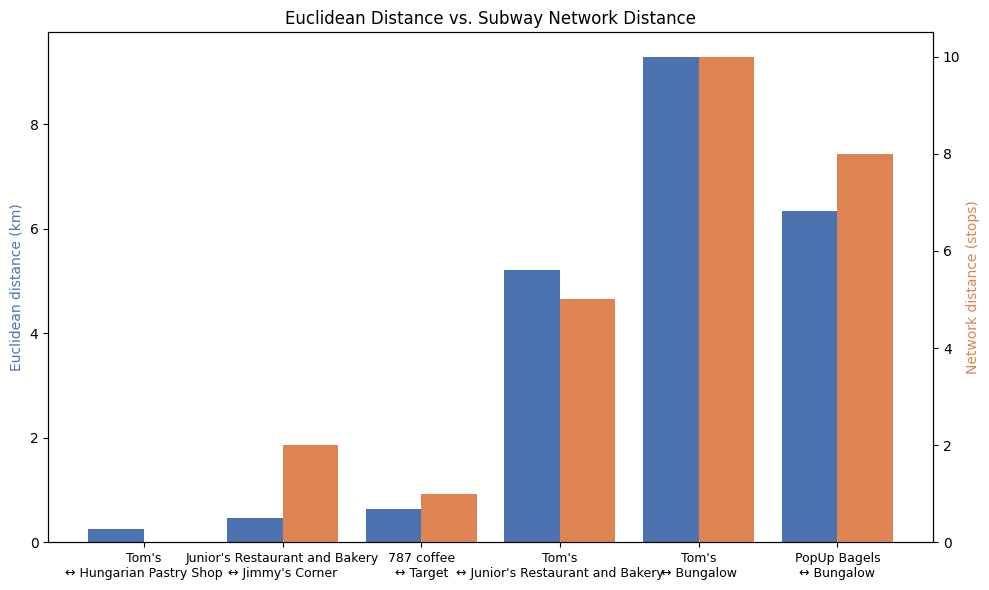

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x = range(len(results_df))
labels = [f"{a}\n↔ {b}" for a, b in zip(results_df["place_a"], results_df["place_b"])]

ax1.bar(
    [i - 0.2 for i in x],
    results_df["euclidean_km"],
    width=0.4,
    label="Euclidean (km)",
    color="#4C72B0",
)
ax1.set_ylabel("Euclidean distance (km)", color="#4C72B0")

ax2 = ax1.twinx()
ax2.bar(
    [i + 0.2 for i in x],
    results_df["network_stops"],
    width=0.4,
    label="Network (stops)",
    color="#DD8452",
)
ax2.set_ylabel("Network distance (stops)", color="#DD8452")

ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, fontsize=9)
plt.title("Euclidean Distance vs. Subway Network Distance")
fig.tight_layout()
plt.show()

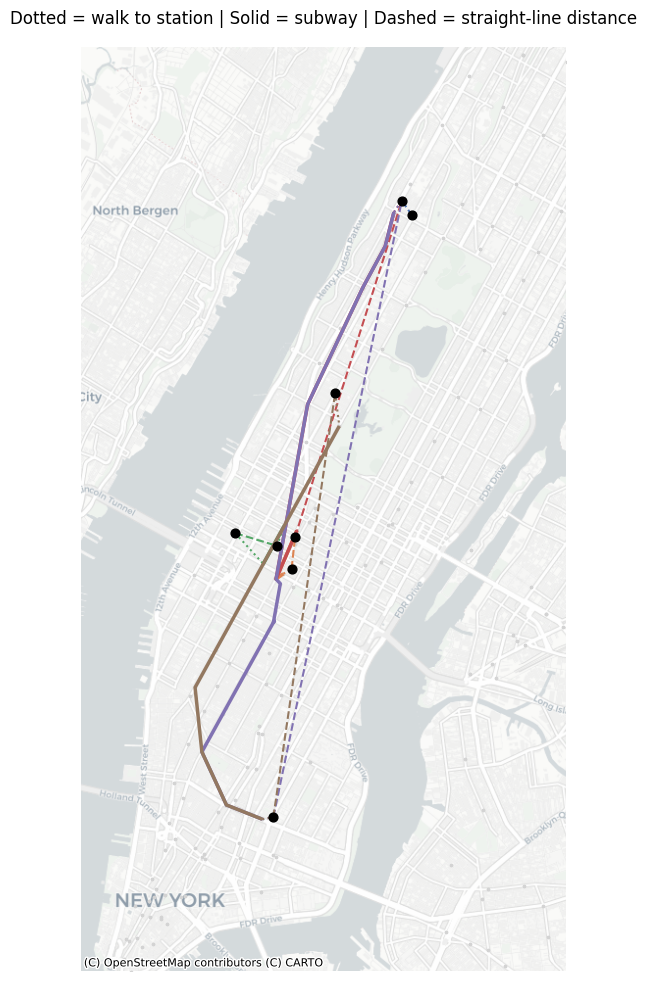

In [27]:
from shapely.geometry import LineString

fig, ax = plt.subplots(figsize=(12, 12))

# Plot all subway stations lightly in the background
station_gdf_crs.to_crs(epsg=3857).plot(ax=ax, color="lightgray", markersize=3, zorder=1)

# Plot your 8 places
subset_web = subset.to_crs(epsg=3857)
subset_web.plot(ax=ax, color="black", markersize=40, zorder=3)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

for i, (a_name, b_name) in enumerate(pairs):
    row_a = get_place_row(a_name)
    row_b = get_place_row(b_name)

    # Straight Euclidean line (dashed)
    straight = gpd.GeoSeries(
        [LineString([row_a.geometry, row_b.geometry])], crs="EPSG:4326"
    ).to_crs(epsg=3857)
    straight.plot(ax=ax, color=colors[i], linestyle="--", linewidth=1.5, zorder=2)

    # Actual subway path (solid, following real stations)
    station_a = place_to_station[row_a["label"]]
    station_b = place_to_station[row_b["label"]]
    try:
        path_nodes = nx.shortest_path(G, station_a, station_b)
        if len(path_nodes) >= 2:
            path_coords = [(G.nodes[n]["lon"], G.nodes[n]["lat"]) for n in path_nodes]
            path_line = gpd.GeoSeries(
                [LineString(path_coords)], crs="EPSG:4326"
            ).to_crs(epsg=3857)
            path_line.plot(
                ax=ax, color=colors[i], linestyle="-", linewidth=2.5, zorder=2
            )

            # Walk connector: place A -> its station
            station_a_point = (G.nodes[station_a]["lon"], G.nodes[station_a]["lat"])
            walk_a = gpd.GeoSeries(
                [LineString([row_a.geometry, station_a_point])], crs="EPSG:4326"
            ).to_crs(epsg=3857)
            walk_a.plot(ax=ax, color=colors[i], linestyle=":", linewidth=1.5, zorder=2)

            # Walk connector: place B -> its station
            station_b_point = (G.nodes[station_b]["lon"], G.nodes[station_b]["lat"])
            walk_b = gpd.GeoSeries(
                [LineString([row_b.geometry, station_b_point])], crs="EPSG:4326"
            ).to_crs(epsg=3857)
            walk_b.plot(ax=ax, color=colors[i], linestyle=":", linewidth=1.5, zorder=2)
    except nx.NetworkXNoPath:
        pass

minx, miny, maxx, maxy = subset_web.total_bounds
buffer = 3000
ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + buffer)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title(
    "Dotted = walk to station | Solid = subway | Dashed = straight-line distance"
)
ax.set_axis_off()
plt.show()

In [25]:
for i, (a_name, b_name) in enumerate(pairs):
    row_a = get_place_row(a_name)
    row_b = get_place_row(b_name)
    station_a = place_to_station[row_a["label"]]
    station_b = place_to_station[row_b["label"]]
    path_nodes = nx.shortest_path(G, station_a, station_b)
    print(f"{colors[i]} | {a_name} ↔ {b_name}: {len(path_nodes)} nodes in path")

#4C72B0 | Tom's ↔ Hungarian Pastry Shop: 1 nodes in path
#DD8452 | Junior's Restaurant and Bakery ↔ Jimmy's Corner: 3 nodes in path
#55A868 | 787 coffee ↔ Target: 2 nodes in path
#C44E52 | Tom's ↔ Junior's Restaurant and Bakery: 6 nodes in path
#8172B2 | Tom's ↔ Bungalow: 11 nodes in path
#937860 | PopUp Bagels ↔ Bungalow: 9 nodes in path


# Assignment 3: Networks

## Research Question
How different is the straight-line (Euclidean) distance between the places in my 
daily life from the actual distance I'd travel via the NYC subway network? What 
does that gap reveal about how transit shapes my sense of what's "close"?

## Reflection: Euclidean vs. Network Distance

**What the data shows:** For very short trips, like Tom's Restaurant to Hungarian 
Pastry Shop, the subway network offers no real advantage. Both places share the 
same nearest station entirely, meaning walking is clearly the faster and more 
practical choice, even though a subway line runs right through the neighborhood.

For longer trips, like Tom's Restaurant to Bungalow, spanning almost the full 
length of Manhattan, the network distance in stops scales roughly with the 
straight-line distance. The map shows the subway's actual path staying fairly 
close to the direct line, since the subway grid runs largely north to south 
along the same axis as this trip.

**The experiential takeaway:** Euclidean distance treats all directions equally, 
but the subway network does not. It rewards trips that align with its own north 
to south structure and penalizes trips that do not, or that are too short to be 
worth the walk to a platform and the wait for a train in the first place. Living 
near a subway line does not mean everything nearby is close in a meaningful, 
practical sense. It means some places are close, and others just happen to be 
geographically near without being easy to reach.

**A limitation worth naming:** This analysis measures distance in number of stops, 
not travel time. A trip with fewer stops but requiring a transfer between lines 
could easily take longer in practice than a trip with more stops on a single, 
direct line. A more complete version of this project would incorporate actual 
travel time using the GTFS schedule data rather than stop count alone.